# Setup

In [1]:
# รันทุกครั้ง
import os
import time
import numpy as np
import pandas as pd
import faiss
import hnswlib
from sklearn.cluster import MiniBatchKMeans
import numpy.linalg as LA
from collections import defaultdict
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter, LogLocator
import h5py
import psutil

# BASE = os.path.dirname(os.path.abspath(__file__))
BASE = os.path.expanduser("~/Downloads/ANN_Hybrid_GloVe1M_test")
print(f"Project base path set to: {BASE}")

folders = [
    "data/glove",
    "indexes/pq",
    "indexes/hnsw_global",
    "indexes/faiss_hnsw",
    "indexes/hnsw_pq",
    "indexes/hannis/glove",
    "logs/pq","logs/hnsw","logs/faiss_hnsw","logs/hnsw_pq","logs/hannis","logs/hybrid", # เก็บบันทึกการทำงาน
    "results","figs" # เก็บผลลัพธ์ที่ได้, เก็บภาพกราฟ
]
for d in folders:
    os.makedirs(os.path.join(BASE, d), exist_ok=True)

dataset_dir = os.path.join(BASE, "data", "glove")
hdf5_path = os.path.join(dataset_dir, "glove-25-angular.hdf5")

pq_index_path = os.path.join(BASE, "indexes", "pq", "glove_ivfpq.index")
hnsw_path = os.path.join(BASE, "indexes", "hnsw_global", "glove_hnsw.bin")
faisshnsw_index_path = os.path.join(BASE, "indexes", "faiss_hnsw", "glove_faiss_hnsw.index")
hnswpq_index_path = os.path.join(BASE, "indexes", "hnsw_pq", "glove_hnswpq.index")

HANNIS_DIR = os.path.join(BASE, "indexes/hannis/glove")
os.makedirs(HANNIS_DIR, exist_ok=True)

hdir = HANNIS_DIR

FIG_DIR = os.path.join(BASE, "figs")
os.makedirs(FIG_DIR, exist_ok=True)

KS = (5,10,20,50,100)
RUNS = 100                 # จำนวนรอบซ้ำต่อการทดสอบ
DATASET = "GloVe1M"

print("Env ready:", BASE, "| DATASET:", DATASET)

Project base path set to: /Users/bew/Downloads/ANN_Hybrid_GloVe1M_test
Env ready: /Users/bew/Downloads/ANN_Hybrid_GloVe1M_test | DATASET: GloVe1M


# L2-normalize for GloVe1M

In [2]:
with h5py.File(hdf5_path, 'r') as f:
    keys = list(f.keys())
    print(f"ชื่อชุดข้อมูลทั้งหมดที่มี: {keys}\n")
    distances_raw = np.array(f['distances'])
    X_raw = np.array(f['train'])
    Q_raw = np.array(f['test'])
    GT = np.array(f['neighbors'])

ชื่อชุดข้อมูลทั้งหมดที่มี: ['distances', 'neighbors', 'test', 'train']



In [ ]:

# สุ่มสร้าง Learn set ดิบ จำนวน 100,000 ตัว
np.random.seed(42)
learn_indices = np.random.choice(X_raw.shape[0], 100000, replace=False)
X_learn_raw = X_raw[learn_indices].copy()

In [3]:
distances_raw

array([[0.10799219, 0.11680873, 0.11747853, ..., 0.15511827, 0.1553804 ,
        0.15557039],
       [0.09305892, 0.10670168, 0.11226702, ..., 0.15710534, 0.1576856 ,
        0.15770923],
       [0.12183118, 0.12335575, 0.13013312, ..., 0.20150936, 0.2016397 ,
        0.20181862],
       ...,
       [0.06147444, 0.07705573, 0.0795581 , ..., 0.12698822, 0.12714605,
        0.12735862],
       [0.12431343, 0.17700318, 0.21019004, ..., 0.29254857, 0.2929914 ,
        0.29304233],
       [0.07969256, 0.08111899, 0.08342765, ..., 0.13623561, 0.13629223,
        0.13637388]], shape=(10000, 100), dtype=float32)

In [4]:
X_raw

array([[-0.28572 ,  1.603   , -0.23369 , ..., -1.0339  ,  0.050656,
         0.13964 ],
       [-2.3121  , -1.0691  ,  0.3303  , ...,  1.978   , -0.34806 ,
         0.82449 ],
       [-0.6794  , -1.4217  ,  1.8045  , ...,  1.0594  , -1.5747  ,
         0.37254 ],
       ...,
       [-1.6796  ,  0.34109 ,  0.28222 , ...,  0.37501 ,  0.28026 ,
        -2.1737  ],
       [ 0.082508,  0.18525 , -0.45625 , ..., -0.88923 , -1.1104  ,
        -0.53628 ],
       [-1.3621  , -1.5107  , -0.86847 , ..., -1.9565  , -0.39212 ,
        -2.0847  ]], shape=(1183514, 25), dtype=float32)

In [5]:
Q_raw

array([[-0.633    , -0.33511  ,  0.52545  , ..., -0.92318  ,  0.42094  ,
         0.4587   ],
       [ 0.39619  ,  0.88522  , -0.1074   , ...,  0.54569  ,  0.73931  ,
        -0.45578  ],
       [-0.66313  , -1.7151   , -0.0026637, ...,  0.19081  , -0.80581  ,
        -0.11503  ],
       ...,
       [-0.96064  ,  2.1524   , -1.0344   , ...,  1.2841   ,  1.159    ,
         1.1649   ],
       [-0.97124  , -0.27788  ,  1.0977   , ..., -0.59059  , -1.9969   ,
        -0.39266  ],
       [-0.38729  ,  1.9016   ,  1.2679   , ...,  0.57668  , -1.0719   ,
         0.69807  ]], shape=(10000, 25), dtype=float32)

In [6]:
GT

array([[1086211, 1034304,  377924, ...,  542027,  544572,  598352],
       [ 116690,  867430,  248320, ...,  889433,  653306, 1100145],
       [ 824549,  300484,  894365, ..., 1156280,  664242,  488836],
       ...,
       [1180096,  524121,  237828, ...,  115324,  184130, 1145645],
       [ 214774, 1029406,  211763, ...,  670035,  795142,  550836],
       [ 382472,  247071,  729484, ...,  549783,  588233, 1025274]],
      shape=(10000, 100), dtype=int32)

In [ ]:
def l2norm(X):
    n = np.linalg.norm(X, axis=1, keepdims=True) + 1e-12
    return (X/n).astype('float32')

Xb = l2norm(X_raw)
Q = l2norm(Q_raw)
X_learn = l2norm(X_learn_raw)

# save
np.save(os.path.join(dataset_dir, "glove_base.npy"), Xb)
np.save(os.path.join(dataset_dir, "glove_query.npy"), Q)
np.save(os.path.join(dataset_dir, "glove_gt_top100.npy"), GT)
np.save(os.path.join(dataset_dir, "glove_learn.npy"), X_learn)

print(f"Base (X) shape: {Xb.shape}")
print(f"Query (Q) shape: {Q.shape}")
print(f"Ground truth (GT) shape: {GT.shape}")
print(f"Learn (X_learn) shape: {X_learn.shape}")

In [7]:
# Load (run ทุกครั้ง)
X  = np.load(os.path.join(dataset_dir, "glove_base.npy")).astype('float32')
Q  = np.load(os.path.join(dataset_dir, "glove_query.npy")).astype('float32')
GT = np.load(os.path.join(dataset_dir, "glove_gt_top100.npy"))
X_learn = np.load(os.path.join(dataset_dir, "glove_learn.npy")).astype('float32')

d  = X.shape[1]
X.shape, Q.shape, GT.shape, X_learn.shape

((1183514, 25), (10000, 25), (10000, 100), (100000, 25))

In [8]:
X

array([[-0.07152991,  0.40131056, -0.05850422, ..., -0.25883654,
         0.01268171,  0.03495883],
       [-0.3540671 , -0.16371831,  0.05058101, ...,  0.30290416,
        -0.05330072,  0.12625958],
       [-0.11959594, -0.2502643 ,  0.31764922, ...,  0.18648799,
        -0.27719712,  0.06557886],
       ...,
       [-0.3972656 ,  0.08067594,  0.06675179, ...,  0.08869884,
         0.0662882 , -0.5141321 ],
       [ 0.01922768,  0.04317069, -0.10632458, ..., -0.2072263 ,
        -0.25876778, -0.12497477],
       [-0.27464953, -0.3046128 , -0.17511556, ..., -0.3945025 ,
        -0.07906584, -0.42035234]], shape=(1183514, 25), dtype=float32)

In [9]:
Q

array([[-0.17031723, -0.09016589,  0.14137945, ..., -0.24839409,
         0.11325962,  0.12341946],
       [ 0.09852021,  0.22012687, -0.02670706, ...,  0.13569625,
         0.18384357, -0.11333841],
       [-0.13885805, -0.35913843, -0.00055777, ...,  0.03995522,
        -0.16873495, -0.02408705],
       ...,
       [-0.15411425,  0.34530678, -0.16594747, ...,  0.20600653,
         0.1859369 ,  0.1868834 ],
       [-0.1291931 , -0.03696324,  0.14601465, ..., -0.07855952,
        -0.26562506, -0.05223113],
       [-0.08111896,  0.3982954 ,  0.2655652 , ...,  0.12078723,
        -0.22451243,  0.1462127 ]], shape=(10000, 25), dtype=float32)

In [10]:
X_learn

array([[-0.36812332, -0.14016995,  0.01436048, ...,  0.06604389,
        -0.07558527, -0.0017589 ],
       [-0.05338118,  0.1172246 , -0.27606803, ..., -0.30303282,
         0.30600217, -0.22588359],
       [-0.2383667 ,  0.03703504,  0.10973752, ..., -0.30174524,
        -0.30939606,  0.16826212],
       ...,
       [ 0.14767909,  0.08399016,  0.0546855 , ..., -0.20404257,
         0.13550235, -0.05999338],
       [ 0.55324644, -0.14099589,  0.25338805, ..., -0.2263387 ,
         0.1116329 ,  0.22007443],
       [-0.09212909,  0.43341762, -0.13457261, ...,  0.14327428,
        -0.02334693,  0.2180942 ]], shape=(100000, 25), dtype=float32)

# Matrics Evalution

In [11]:
print("KS=", KS, "RUNS=", RUNS, "DATASET=", DATASET)

KS= (5, 10, 20, 50, 100) RUNS= 100 DATASET= GloVe1M


In [12]:
def precision_at_k(gt, pred, k):
    # สัดส่วนผลที่คืนมาถูกต้องใน top-k
    return float(np.mean([len(set(g[:k]) & set(p[:k])) / max(1, len(p[:k])) for g,p in zip(gt,pred)]))

def recall_at_k(gt, pred, k):
    # วัดความครอบคลุมที่ top-k จะเท่ากับ precision_at_k ในงานนี้
    return float(np.mean([len(set(g[:k]) & set(p[:k])) / max(1, len(g[:k])) for g,p in zip(gt,pred)]))

def f1_from_pr(p, r):
    # วัดความสมดุลระหว่าง Precision และ Recall
    return 0.0 if (p+r)==0 else 2*p*r/(p+r)

def bench_many(name, search_fn, Q, GT, ks=KS, runs=RUNS, warm_k=10, log_csv=None):

    warm_up_count = min(len(Q), 100)
    _ = search_fn(Q[:warm_up_count], warm_k)  # warm-up

    perq_times, perq_load = [], []
    P, R = {k:[] for k in ks}, {k:[] for k in ks}
    for r_idx in range(runs):
        t0 = time.perf_counter() # เริ่มจับเวลา retrieval รวม ของ search_fn
        out = search_fn(Q, max(ks)) # รันฟังก์ชันค้นหา
        if isinstance(out, tuple):
            I, load_t = out
        else:
            I, load_t = out, 0.0
        dt = time.perf_counter() - t0 # หยุดเวลา และคำนวณส่วนต่าง
        perq_times.append(dt/len(Q)) # หารด้วยจำนวนคำถาม เพื่อหาเวลาเฉลี่ย "ต่อ 1 ข้อ"
        perq_load.append(load_t/len(Q))

        print(f"Run {r_idx+1}/{runs}: {dt:.4f}s (Avg {dt/len(Q)*1000:.3f}ms/q)")

        for k in ks:
            p = precision_at_k(GT, I, k)
            r = recall_at_k(GT, I, k)
            P[k].append(p); R[k].append(r)

    row = {
        "dataset": DATASET,
        "method": name,
        "latency_mean_s_per_query": float(np.mean(perq_times)),
        "latency_p95_s_per_query":  float(np.percentile(perq_times, 95)),
        "index_loading_s_per_query": float(np.mean(perq_load)),
    }
    for k in ks:
        p, r = float(np.mean(P[k])), float(np.mean(R[k]))
        row[f"precision@{k}"] = p
        row[f"recall@{k}"]    = r
        row[f"f1@{k}"]        = f1_from_pr(p, r)

    if log_csv:
        pd.DataFrame([row]).to_csv(log_csv, mode='a',
                                   header=not os.path.exists(log_csv), index=False)
    return row

# วัด Retrieval-only (สำหรับ PQ/HNSW)

In [13]:

def bench_search_only(name, index_obj, search_func, Q, GT, ks=KS, runs=RUNS, warm_k=10, log_csv=None):

    warm_up_count = min(len(Q), 100)
    _ = search_func(index_obj, Q[:warm_up_count], warm_k)  # warm-up

    perq_times = []
    P, R = {k:[] for k in ks}, {k:[] for k in ks}
    for r_idx in range(runs):
        t0 = time.perf_counter() # เริ่มจับเวลา retrieval รวม ของ search_fn
        I = search_func(index_obj, Q, max(ks)) # รันฟังก์ชันค้นหา
        dt = time.perf_counter() - t0 # หยุดเวลา และคำนวณส่วนต่าง
        perq_times.append(dt/len(Q)) # หารด้วยจำนวนคำถาม เพื่อหาเวลาเป็น ms/query

        print(f"Run {r_idx+1}/{runs}: {dt:.4f}s (Avg {dt/len(Q)*1000:.3f}ms/q)")

        for k in ks:
            p = precision_at_k(GT, I, k)
            r = recall_at_k(GT, I, k)
            P[k].append(p); R[k].append(r)

    row = {
        "dataset": DATASET,
        "method": name,
        "latency_mean_s_per_query": float(np.mean(perq_times)),
        "latency_p95_s_per_query":  float(np.percentile(perq_times, 95)),
    }
    for k in ks:
        p, r = float(np.mean(P[k])), float(np.mean(R[k]))
        row[f"precision@{k}"] = p
        row[f"recall@{k}"]    = r
        row[f"f1@{k}"]        = f1_from_pr(p, r)

    if log_csv:
        pd.DataFrame([row]).to_csv(log_csv, mode='a',
                                   header=not os.path.exists(log_csv), index=False)
    return row

# PQ (Build index)

In [ ]:
# run ครั้งเดียว
def build_ivfpq(X_train, X_add, nlist=1024, m=5, nbits=8,
# nlist=256: แบ่งข้อมูลเป็น 256 คลัสเตอร์, m=5 คือแบ่งเวกเตอร์ 25 มิติ ออกเป็น 5 ส่วน (ส่วนละ 5 มิติ), nbits=8: ใช้ 8 บิตแทนค่าในแต่ละส่วน
                add_bs=100000, save_path=None):
    d = X_train.shape[1]
    coarse = faiss.IndexFlatL2(d) # วัดระยะทางแบบ Euclidean
    index  = faiss.IndexIVFPQ(coarse, d, nlist, m, nbits)

    # Train
    t0 = time.perf_counter() #จับเวลา Train
    index.train(X_train.astype("float32"))
    t_train = time.perf_counter() - t0 # หยุดจับเวลาแล้วคำนวณการใช้เวลา Train

    # Add base vectors บีบอัดเข้า index ทีละก้อน (Batch)
    t0 = time.perf_counter()
    for i in range(0, X_add.shape[0], add_bs):
        index.add(X_add[i:i+add_bs].astype("float32"))
    t_add = time.perf_counter() - t0 # บันทึกเวลาที่ใช้ในการ Add ข้อมูล

    if save_path is not None:
        faiss.write_index(index, save_path)

    return index, t_train, t_add

ivf_nlist, pq_m, pq_nbits = 1024, 5, 8
pq_index_path = os.path.join(BASE, "indexes", "pq", "glove_ivfpq.index")

ivfpq, pq_t_train, pq_t_add = build_ivfpq( # เรียกใช้ฟังก์ชัน
    X_learn,  # ใช้ learn set สำหรับ train (X_train=X_learn)
    X,        # ใช้ base สำหรับ add เข้า index ( X_add=X)
    nlist=ivf_nlist,
    m=pq_m,
    nbits=pq_nbits,
    add_bs=100000,
    save_path=pq_index_path
)

pq_build_row = {
    "dataset": DATASET, "method": "PQ(IVF-PQ)",
    "build_seconds": pq_t_train + pq_t_add,
    "index_size_mb": os.path.getsize(pq_index_path)/1e6
}
pd.DataFrame([pq_build_row]).to_csv(os.path.join(BASE, "logs", "pq", "build_times.csv"),
                                    mode='a', header=not os.path.exists(os.path.join(BASE, "logs", "pq", "build_times.csv")), index=False)
pq_build_row

# HNSW (Build index)

In [ ]:
# run ครั้งเดียว
def build_hnsw(X, M=16, efC=200, save_path=None): # X = Base set, M = จำนวนเส้นเชื่อมต่อ, efC = ความละเอียดตอนสร้าง
    index = hnswlib.Index(space='l2', dim=X.shape[1])
    t0 = time.perf_counter()
    index.init_index(max_elements=X.shape[0], ef_construction=efC, M=M) # จองพื้นที่ RAM
    index.add_items(X, np.arange(X.shape[0])) # นำข้อมูล X ใส่เข้าไป พร้อมกับกำหนด ID ให้แต่ละตัว
    build_time = time.perf_counter() - t0
    if save_path:
        index.save_index(save_path)
    return index, build_time

hnsw_path = os.path.join(BASE, "indexes", "hnsw_global", "glove_hnsw.bin")
hnsw, hnsw_build = build_hnsw(X, M=16, efC=200, save_path=hnsw_path)

hnsw_build_row = {
    "dataset": DATASET, "method": "HNSWlib",
    "build_seconds": hnsw_build,
    "index_size_mb": os.path.getsize(hnsw_path)/1e6
}
pd.DataFrame([hnsw_build_row]).to_csv(os.path.join(BASE, "logs", "hnsw", "build_times.csv"),
                                      mode='a', header=not os.path.exists(os.path.join(BASE, "logs", "hnsw", "build_times.csv")), index=False)
hnsw_build_row

# **FaissHNSW (Build index)**

In [ ]:
# run ครั้งเดียว (สร้าง FAISS HNSW แบบกราฟบริสุทธิ์)

def build_faiss_hnsw_flat(X_add, M=16, efC=200, save_path=None):
    d = X_add.shape[1]

    # ใช้ IndexHNSWFlat (เก็บข้อมูลดิบ)
    index = faiss.IndexHNSWFlat(d, M)

    # Add (ใส่ข้อมูลเข้ากราฟเลย ไม่ต้อง Train)
    t0 = time.perf_counter()
    index.hnsw.efConstruction = efC
    index.add(X_add.astype("float32"))
    t_add = time.perf_counter() - t0

    if save_path is not None:
        faiss.write_index(index, save_path)

    # วิธี Flat ไม่ต้อง Train เลยส่งเวลา train เป็น 0.0
    return index, 0.0, t_add

faisshnsw_index, faisshnsw_t_train, faisshnsw_t_add = build_faiss_hnsw_flat(
    X, M=16, efC=200, save_path=faisshnsw_index_path
)

faisshnsw_build_row = {
    "dataset": DATASET, "method": "FaissHNSW",
    "build_seconds": faisshnsw_t_train + faisshnsw_t_add,
    "index_size_mb": os.path.getsize(faisshnsw_index_path)/1e6
}

# บันทึก log ลงโฟลเดอร์ใหม่ (logs/faiss_hnsw)
faisshnsw_log_path = os.path.join(BASE, "logs", "faiss_hnsw", "build_times.csv")
pd.DataFrame([faisshnsw_build_row]).to_csv(faisshnsw_log_path,
                                        mode='a', header=not os.path.exists(faisshnsw_log_path), index=False)
faisshnsw_build_row

# HNSW+PQ (Build index)

In [ ]:
# run ครั้งเดียว (สร้าง HNSW-PQ Index)
def build_hnsw_pq(X_train, X_add, M=16, m=5, efC=200, save_path=None):
    # M = จำนวนเส้นเชื่อม (ให้เท่ากับ HNSWlib)
    # m = จำนวนส่วนที่โดนหั่นใน PQ (ให้เท่ากับ IVF-PQ)
    d = X_train.shape[1]

    # สร้าง Index แบบ HNSW + PQ ของ FAISS
    index = faiss.IndexHNSWPQ(d, m, M)

    # Train (หา Centroids ของ PQ)
    t0 = time.perf_counter()
    index.hnsw.efConstruction = efC
    index.train(X_train.astype("float32"))
    t_train = time.perf_counter() - t0

    # Add (ใส่ข้อมูลเข้ากราฟ HNSW)
    t0 = time.perf_counter()
    index.add(X_add.astype("float32"))
    t_add = time.perf_counter() - t0

    if save_path is not None:
        faiss.write_index(index, save_path)

    return index, t_train, t_add

hnswpq_index_path = os.path.join(BASE, "indexes", "hnsw_pq", "glove_hnswpq.index")
hnswpq_index, hnswpq_t_train, hnswpq_t_add = build_hnsw_pq(
    X_learn, X, M=16, m=5, efC=200, save_path=hnswpq_index_path
)

hnswpq_build_row = {
    "dataset": DATASET, "method": "HNSW-PQ(FAISS)",
    "build_seconds": hnswpq_t_train + hnswpq_t_add,
    "index_size_mb": os.path.getsize(hnswpq_index_path)/1e6
}
pd.DataFrame([hnswpq_build_row]).to_csv(os.path.join(BASE, "logs", "hnsw_pq", "build_times.csv"),
                                        mode='a', header=not os.path.exists(os.path.join(BASE, "logs", "hnsw_pq", "build_times.csv")), index=False)
hnswpq_build_row

# HANNIS (Build index)

In [ ]:
# run ครั้งเดียว
# Cluster + HNSW per-cluster
K_h = 4  # แบ่งเป็น 4 Clusters
t0 = time.perf_counter()

# สร้างโมเดลเพื่อใช้แบ่ง clusters
km = MiniBatchKMeans(
    n_clusters=K_h,
    batch_size=4096,
    random_state=42,
    n_init="auto"
)

# ---- Train k-means เฉพาะบน X_learn ----
km.fit(X_learn) # สร้าง Centroids จากข้อมูล learn
centroids = km.cluster_centers_.astype('float32')

# ---- Assign cluster ให้เวกเตอร์ในฐานข้อมูล (X = base) ----
labels = km.predict(X) # เอาข้อมูล Base เทียบกับ Centroids

t_cluster = time.perf_counter() - t0

np.save(os.path.join(hdir, "centroids.npy"), centroids)
np.save(os.path.join(hdir, "id_to_cluster.npy"), labels)

# สร้าง HNSW ต่อคลัสเตอร์ (label= id)
t0 = time.perf_counter()
for c in range(K_h):
    idxs = np.where(labels==c)[0] # หาว่าใครอยู่กลุ่มนี้บ้าง
    if idxs.size == 0: continue
    xb = X[idxs] # ดึงเวกเตอร์ของกลุ่มนี้มา
    h = hnswlib.Index(space='l2', dim=d) # สร้าง HNSW เล็กๆ เฉพาะกลุ่มนี้
    h.init_index(max_elements=xb.shape[0], ef_construction=200, M=16) # พารามิเตอร์เท่า HNSWlib
    h.add_items(xb, idxs) # ใส่ข้อมูล พร้อมระบุ ID เดิม
    h.save_index(os.path.join(hdir, f"hnsw_cluster_{c}.bin"))
t_hnsw_clusters = time.perf_counter() - t0

hannis_build_row = {
    "dataset": DATASET, "method": "HANNIS-basic",
    "build_seconds": t_cluster + t_hnsw_clusters,
    "cluster_seconds": t_cluster,
    "percluster_hnsw_seconds": t_hnsw_clusters,
    "index_size_mb_total": float(sum(os.path.getsize(os.path.join(hdir, f"hnsw_cluster_{c}.bin"))
                                     for c in range(K_h) if os.path.exists(os.path.join(hdir, f"hnsw_cluster_{c}.bin"))))/1e6
}
pd.DataFrame([hannis_build_row]).to_csv(os.path.join(BASE, "logs", "hannis", "build_times.csv"),
                                        mode='a', header=not os.path.exists(os.path.join(BASE, "logs", "hannis", "build_times.csv")), index=False)
hannis_build_row

# Search function (HANNIS & Hybrid)

In [14]:

def load_all_hannis_clusters_to_ram(hannis_dir, d, total_clusters):

    # ฟังก์ชันสำหรับโหลดกราฟย่อยทั้งหมดขึ้น RAM เก็บไว้ใน Dictionary
    loaded_indexes = {}
    print(f"กำลังโหลด {total_clusters} กราฟย่อยเข้าสู่ RAM...")

    for cid in range(total_clusters):
        index_path = os.path.join(hannis_dir, f"hnsw_cluster_{cid}.bin")
        if os.path.exists(index_path):
            h = hnswlib.Index(space="l2", dim=d)
            h.load_index(index_path)
            loaded_indexes[cid] = h  # เก็บกราฟที่โหลดแล้วไว้ใน RAM

    print(f"โหลดเสร็จสิ้น!")
    return loaded_indexes

In [15]:
# HANNIS: เลือก top-G centroids ใกล้คิวรี → โหลด HNSW ของคลัสเตอร์เหล่านั้นแบบ on-demand → รวมผลให้ครบ k
def hannis_search(Q, loaded_hannis_ram, C, k=100, topG=4, ef_base=120): # Q=ชุด query, topG=จำนวนคลัสเตอร์เริ่มต้นที่เข้าไปค้นหา, ef_base=ค่าความละเอียดในการค้นหาภายในกราฟ HNSW ย่อย
    """
    HANNIS:
      1) เลือก topG centroids ใกล้ query
      2) สำหรับแต่ละคลัสเตอร์ -> load HNSW แล้ว search top-k (ขอ k เต็ม)
      3) merge ผลทั้งหมด แล้ว sort distance เลือก top-k สุดท้าย
    """
    out = []

    # วนลูปคิวรี่
    for q in Q:
        # หาระยะห่างจากคิวรี่ไปคลัสเตอร์
        distances = {}
        for index, c in enumerate(C):
            dist = LA.norm(c - q)
            distances[index] = dist

        # เรียงคลัสเตอร์จาก centroid ที่ใกล้ที่สุดไปไกลที่สุด
        sorted_distances = dict(sorted(distances.items(), key=lambda item: item[1]))

        # ที่เก็บผลลัพธ์ใช้ List ว่าง
        final_data = []

        # วนลูปเข้าคลัสเตอร์ตามจำนวน topG
        for i in range(min(topG, len(sorted_distances))):
            # ดึง ID ของคลัสเตอร์ตามลำดับที่เรียงไว้
            c_idx = list(sorted_distances.keys())[i]

            if c_idx not in loaded_hannis_ram:
                continue

            h = loaded_hannis_ram[c_idx]
            cnt = h.get_current_count()
            if cnt <= 0:
                continue

            # ถ้าคลัสเตอร์มีข้อมูลไม่ถึง k ก็ขอได้แค่เท่าที่มี
            kc = min(k, cnt)
            h.set_ef(ef_base)

            # ค้นหาในกราฟย่อย
            labs, dists = h.knn_query(np.expand_dims(q, axis=0), k=kc)

            # เอาผลแต่ละตัวมายัดรวมใน final_data
            for label, dist in zip(labs[0], dists[0]):
                final_data.append((label, dist))

        # Sort รวดเดียว
        if len(final_data) > 0:
            # เอาผลจากทุกคลัสเตอร์มาเรียงใหม่โดยดูว่าใครใกล้ query ที่สุด
            sorted_final_data = sorted(final_data, key=lambda x: x[1])

            # ตัดหางเอาแค่ k ตัวแรก
            best_k = sorted_final_data[:k]

            # ดึงเฉพาะ label ออกมา
            final_labels = [item[0] for item in best_k if item[0] != -1]
            out.append(final_labels)
        else:
            out.append([])

    return np.array(out, dtype=object), 0.0

In [16]:

def make_hybrid_pq_hannis_search(
    pq_index,
    id_to_cluster_map,
    loaded_hannis_ram,
    centroids,
    prefilter_k=16000,
    ef_base=120,
    topG=32,
    pq_batch_size=128,   # เพิ่ม batch ย่อยเพื่อลดแรม
):
    """
    Hybrid(PQ -> HANNIS) แบบลด RAM แต่คงแนวคิดเดิม:
      - PQ prefilter
      - map candidate -> cluster
      - เลือก topG clusters ต่อ query
      - task assignment เป็นราย cluster
      - HANNIS search แบบ batch
      - merge ผลแล้วเลือก top-k
    """

    C = centroids.astype(np.float32, copy=False)
    id_to_cluster_map = id_to_cluster_map.astype(np.int32, copy=False)

    def _search(Q, k=100):
        Q = Q.astype(np.float32, copy=False)
        nQ = Q.shape[0]

        # top-k buffer ของทุก query
        top_dists = np.full((nQ, k), np.inf, dtype=np.float32)
        top_labels = np.full((nQ, k), -1, dtype=np.int32)

        # 1) PQ prefilter + 2) cluster selection + 3) task assignment
        # สร้าง dictionary ที่ key เป็น cluster id และ value เป็น list ของ query index ที่ต้องไปค้น cluster นั้น
        cluster_to_queries = defaultdict(list)

        # วน query แบ่งทีละ batch
        for start in range(0, nQ, pq_batch_size): 
            end = min(start + pq_batch_size, nQ)
            q_batch = Q[start:end]

            # PQ ค้นหา candidate จำนวน prefilter_k ตัว
            _, cand_ids = pq_index.search(q_batch, prefilter_k)

            # ดูผลลัพธ์วนทีละ query ภายใน batch
            for local_qi in range(end - start):
                qi = start + local_qi
                ids = cand_ids[local_qi]
                ids = ids[ids >= 0]
                if ids.size == 0:
                    continue

                # map จาก candidate id ไป cluster id 
                cids = id_to_cluster_map[ids] # เอา candidate ids ทั้งหมดไปดูว่าแต่ละตัวอยู่ cluster ไหน
                uniq, cnt = np.unique(cids, return_counts=True) # นับโหวตว่าคลัสเตอร์ไหนเจอ candidate ถี่สุด

                q_vec = Q[qi]
                diff = C[uniq] - q_vec
                # คำนวณ squared L2 distance ของแต่ละ centroid กับ query
                cen_d = np.einsum("ij,ij->i", diff, diff).astype(np.float32, copy=False)

                # เรียงคลัสเตอร์จากที่โหวตเยอะสุดก่อน ถ้าโหวตเท่ากันดูว่าระยะที่ใกล้สุด
                order = np.lexsort((cen_d, -cnt))
                # เลือก topG อันดับแรก
                picked = uniq[order[:max(1, topG)]]

                # บันทึกว่า query ไหนต้องไปค้น cluster ไหนต่อ
                for cid in picked:
                    cluster_to_queries[int(cid)].append(qi)

            del cand_ids # ลบผลลัพธ์ PQ ทิ้งเพื่อคืน RAM

        # 4) Search per cluster
        temp_d = np.empty(2 * k, dtype=np.float32)
        temp_l = np.empty(2 * k, dtype=np.int32)

        # วนทีละ cluster แทนการวนทีละคิวรี่
        for cid, q_indices in cluster_to_queries.items():
            h = loaded_hannis_ram.get(cid) # โหลดกราฟย่อย
            if h is None:
                continue

            cnt = h.get_current_count()
            if cnt <= 0:
                continue

            # ขอจำนวน k ตัว
            kc = min(k, cnt)
            h.set_ef(ef_base)

            # เอาคิวรี่ทั้งหมดที่คลัสเตอร์นึงต้องค้นหา มาค้นหาทีเดียวแบบ batch processing
            q_batch = Q[q_indices]
            labs, dists = h.knn_query(q_batch, k=kc)

            dists = dists.astype(np.float32, copy=False)
            labs = labs.astype(np.int32, copy=False)

            # 5) merge top-k 
            for ii, qi in enumerate(q_indices):
                # เติมของเดิม
                temp_d[:k] = top_dists[qi]
                temp_l[:k] = top_labels[qi]

                # เติมของใหม่
                temp_d[k:k+kc] = dists[ii]
                temp_l[k:k+kc] = labs[ii]

                total = k + kc

                # คัดเลือก k ตัวที่ดีที่สุด(ระยะใกล้สุด) โดยไม่ต้อง Sort ทั้งหมด
                best_idx = np.argpartition(temp_d[:total], k - 1)[:k]
                # ค่อยมา Sort แค่ k ตัวที่เข้ารอบ
                best_sorted = best_idx[np.argsort(temp_d[best_idx])]

                top_dists[qi] = temp_d[best_sorted]
                top_labels[qi] = temp_l[best_sorted]

        # 6) final output
        out = []
        for qi in range(nQ):
            valid = top_labels[qi][top_labels[qi] != -1]
            out.append(valid.tolist())

        del top_dists, top_labels, cluster_to_queries, temp_d, temp_l
        gc.collect()

        return np.array(out, dtype=object), 0.0

    return _search

# Benchmarking & Summary

In [17]:
# รันกี่ครั้งก็ได้แต่ต้องลบไฟล์ในโฟลเดอร์ logs/pq/{DATASET}_runs.csv และ results/{DATASET}_summary.csv ก่อน
process = psutil.Process(os.getpid())

def get_current_rss_mb():
    # ดึงค่า RAM ที่กำลังใช้งานอยู่ ณ วินาทีนี้
    gc.collect()
    return process.memory_info().rss / (1024 ** 2)

def get_peak_rss_mb():
    # ดึงค่า RAM สูงสุด (High-water mark) ที่โปรเซสนี้เคยแตะถึง
    try:
        import resource
        peak = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
        import sys
        if sys.platform == 'darwin':
            return peak / (1024 ** 2) # Mac
        else:
            return peak / 1024 # Linux
    except ImportError:
        # Fallback สำหรับ Windows
        return get_current_rss_mb()

all_results_list = [] # เตรียมลิสต์ไว้เก็บผลของแต่ละวิธีเพื่อรวมตารางสรุปตอนท้าย

# --- 1) PQ (IVF-PQ): Initial load + Retrieval-only ---
print("\n--- Benchmarking: PQ(IVF-PQ) ---")
gc.collect()
base_rss = get_current_rss_mb() # Jupyter Notebook แอบกิน RAM พื้นหลังอยู่แล้วต้องจดค่าเริ่มต้นนี้ไว้ เพื่อเอาไปลบออกตอนท้าย จะได้รู้ว่าตัวอัลกอริทึมกิน RAM ไปเท่าไหร่

t0 = time.perf_counter() #เริ่มจับเวลาที่โหลด index ครั้งแรก ก่อนเริ่ม benchmark
pq_index = faiss.read_index(pq_index_path) # โหลด PQ index จาก disk → RAM

pq_index.nprobe = 32 # <--- จูน PQ

pq_total_load_time = time.perf_counter() - t0
print(f"PQ Total Index Load Time: {pq_total_load_time:.4f}s")

initial_rss_pq = get_current_rss_mb()
initial_ram_mb = max(0, initial_rss_pq - base_rss) # โหลด Index เข้าสู่ระบบเสร็จ ค่านี้คือ RAM ที่อัลกอริทึมต้องจองไว้ตลอด

# เตรียมฟังก์ชันสำหรับค้นหา
def pq_search_func(index, q_vectors, k):
  D, I = index.search(q_vectors, k) # คำสั่งหลักในการค้นหาของ FAISS
  return I # ID ของคำตอบ

# รันค้นหา
peak_before_search = get_peak_rss_mb()
pq_res = bench_search_only("PQ(IVF-PQ)", pq_index, pq_search_func, Q, GT,
                           log_csv=os.path.join(BASE, "logs", "pq", f"{DATASET}_runs.csv"))
peak_after_search = get_peak_rss_mb()

pq_res['initial_ram_mb'] = initial_ram_mb
pq_res['peak_retrieval_ram_mb'] = max(0, peak_after_search - base_rss) # ค้นหาเสร็จสิ้น ค่าที่เกิดขึ้นระหว่างที่คอมพิวเตอร์กำลังหาคำตอบ (Initial RAM + พื้นที่ของตัวแปร Array เล็กๆ)
pq_res['total_index_load_s'] = pq_total_load_time
# วิธีนี้ไม่มี On-demand loading
pq_res['on_demand_load_s_per_query'] = 0.0
all_results_list.append(pq_res)
# เคลียร์ RAM ทิ้งให้สะอาดเพื่อความยุติธรรมในการวัดวิธีถัดไป
del pq_index; gc.collect()

# --- 2) HNSW-PQ (FAISS): Initial load + Retrieval-only ---
print("\n--- Benchmarking: HNSW-PQ (FAISS) ---")
gc.collect()
base_rss = get_current_rss_mb()

t0 = time.perf_counter()
hnswpq_index = faiss.read_index(hnswpq_index_path) # โหลด Index

hnswpq_index.hnsw.efSearch = 200 # <--- จูนค่า ef ของ HNSW-PQ ให้เท่ากับ HNSWlib

hnswpq_total_load_time = time.perf_counter() - t0
print(f"HNSW-PQ Total Index Load Time: {hnswpq_total_load_time:.4f}s")

initial_rss_hnswpq = get_current_rss_mb()
initial_ram_mb = max(0, initial_rss_hnswpq - base_rss)

# เตรียมฟังก์ชันค้นหาของ HNSW-PQ
def hnswpq_search_func(index, q_vectors, k):
  D, I = index.search(q_vectors, k)
  return I

# รันค้นหา
hnswpq_res = bench_search_only("HNSW-PQ(FAISS)", hnswpq_index, hnswpq_search_func, Q, GT,
                               log_csv=os.path.join(BASE, "logs", "hnsw_pq", f"{DATASET}_runs.csv"))
peak_after_search = get_peak_rss_mb()

hnswpq_res['initial_ram_mb'] = initial_ram_mb
hnswpq_res['peak_retrieval_ram_mb'] = max(0, peak_after_search - base_rss)
hnswpq_res['total_index_load_s'] = hnswpq_total_load_time
hnswpq_res['on_demand_load_s_per_query'] = 0.0
all_results_list.append(hnswpq_res)

del hnswpq_index; gc.collect()

# --- 3) Hybrid (PQ -> HANNIS)---
print("\n--- Benchmarking: Hybrid(PQ->HANNIS) ---")

# แอบอ่านจำนวนคลัสเตอร์จากไฟล์ centroids.npy ก่อน
temp_centroids = np.load(os.path.join(hdir, "centroids.npy"))
num_clusters_auto = temp_centroids.shape[0]  # ดึงจำนวนแถว ซึ่งก็คือจำนวนคลัสเตอร์ทั้งหมด

# จำลองสภาพแวดล้อม โหลดกราฟเตรียมไว้ก่อน
loaded_hannis_ram = load_all_hannis_clusters_to_ram(hdir, d, total_clusters=num_clusters_auto)

gc.collect()
base_rss = get_current_rss_mb()

t0 = time.perf_counter() #เริ่มจับเวลาที่โหลด index ครั้งแรก
# โหลดองค์ประกอบทั้งหมดกลับเข้ามาใหม่เพื่อให้ยุติธรรม
pq_index = faiss.read_index(pq_index_path)
pq_index.nprobe = 32 # <-- จูน PQ

id_to_cluster_map = np.load(os.path.join(hdir, "id_to_cluster.npy"))

# โหลด Centroids
centroids = np.load(os.path.join(hdir, "centroids.npy"))

# เวลาโหลดเริ่มต้นของวิธีนี้ (PQ Index + Mapping + Centroids) โดย pq_index ถูกโหลดไว้แล้ว
hybrid_ph_initial_load_time = pq_total_load_time + (time.perf_counter() - t0)
print(f"Hybrid(PQ->HANNIS) Initial Load Time: {hybrid_ph_initial_load_time:.4f}s")

# คำนวณ Initial RAM (จะได้ขนาดของ PQ + Mapping + Centroids)
initial_rss_hybrid = get_current_rss_mb()
initial_ram_mb = max(0, initial_rss_hybrid - base_rss)

# สร้างฟังก์ชันค้นหา In-Memory
hybrid_pq_hannis_fn = make_hybrid_pq_hannis_search(
    pq_index=pq_index,
    id_to_cluster_map=id_to_cluster_map,
    loaded_hannis_ram=loaded_hannis_ram, # ส่งกราฟที่ซ่อนอยู่ใน RAM เข้าไปหา
    centroids=centroids,
    prefilter_k=4000,    # <--- จูน Hybrid เปลี่ยนค่า prefilter_k ตรงนี้
    topG=3,             # <--- จูน Hybrid เปลี่ยนค่า topG ตรงนี้
    ef_base=200,          # ef_base ให้ฟิกซ์ไว้ที่ 120
    pq_batch_size=128 # แบ่งก้อนชุดคิวรี่
)

# วัดประสิทธิภาพ
peak_before_search = get_peak_rss_mb()
hybrid_ph_res = bench_many("Hybrid(PQ->HANNIS)", hybrid_pq_hannis_fn, Q, GT,
                         log_csv=os.path.join(BASE, "logs", "hybrid", f"{DATASET}_runs.csv"))
peak_after_search = get_peak_rss_mb()

hybrid_ph_res['initial_ram_mb'] = initial_ram_mb # วัดขนาดของ PQ Index + id_to_cluster.npy + centroids.npy
hybrid_ph_res['peak_retrieval_ram_mb'] = max(0, peak_after_search - base_rss) # ตัวแปร Array 160 ล้านช่องระหว่างทำ Prefilter (cand_ids), ตัวแปรลิสต์ bags ที่คอยเก็บสะสม (ระยะทาง, ไอดี) เป็นล้านๆระหว่างวนลู, ขนาดของกราฟย่อย HNSW ที่โหลดขึ้นมาแบบ On-demand
hybrid_ph_res['total_index_load_s'] = hybrid_ph_initial_load_time
hybrid_ph_res['on_demand_load_s_per_query'] = hybrid_ph_res.pop('index_loading_s_per_query')
all_results_list.append(hybrid_ph_res)

del pq_index, id_to_cluster_map, centroids; gc.collect()

# --- 4) HANNIS-basic: Initial load(metadata) + Retrieval(with on-demand load) ---
print("\n--- Benchmarking: HANNIS-basic ---")

# แอบอ่านจำนวนคลัสเตอร์จากไฟล์ centroids.npy ก่อน
temp_centroids = np.load(os.path.join(hdir, "centroids.npy"))
num_clusters_auto = temp_centroids.shape[0]  # ดึงจำนวนแถว ซึ่งก็คือจำนวนคลัสเตอร์ทั้งหมด

# จำลองสภาพแวดล้อม โหลดกราฟเตรียมไว้ก่อน
loaded_hannis_ram = load_all_hannis_clusters_to_ram(hdir, d, total_clusters=num_clusters_auto)

gc.collect()
base_rss = get_current_rss_mb()

t0 = time.perf_counter() #เริ่มจับเวลาที่โหลด index ครั้งแรก
# จับเวลาสำหรับส่วน "Initial Load" (การเตรียมข้อมูลก่อนเริ่มค้นหา)
C_hannis  = np.load(os.path.join(hdir, "centroids.npy"))
hannis_total_load_time = time.perf_counter() - t0
print(f"HANNIS Initial Load (metadata) Time: {hannis_total_load_time:.4f}s")

# คำนวณ Initial RAM (จะได้ค่าเกือบ 0 MB เหมือนเดิม เพราะกราฟถูกหักลบไปกับ base_rss แล้ว)
initial_rss_hannis = get_current_rss_mb()
initial_ram_mb = max(0, initial_rss_hannis - base_rss)

# สร้าง Wrapper เพื่อเปิดช่องให้เราเสียบค่าพารามิเตอร์ของ HANNIS ได้
def hannis_wrapper(q, k_val):
    return hannis_search(
        q,
        loaded_hannis_ram=loaded_hannis_ram,
        C=C_hannis,
        k=k_val,
        topG=3,        # <--- จูน HANNIS
        ef_base=200     # ef_base ให้ฟิกซ์ไว้ที่ 120
    )

# เรียกใช้ฟังก์ชัน bench_many
peak_before_search = get_peak_rss_mb()
hannis_res = bench_many("HANNIS-basic", hannis_wrapper, Q, GT,
                        log_csv=os.path.join(BASE, "logs", "hannis", f"{DATASET}_runs.csv"))
peak_after_search = get_peak_rss_mb()

hannis_res['initial_ram_mb'] = initial_ram_mb # วัดแค่ขนาดของตัวแปร centroids.npy
hannis_res['peak_retrieval_ram_mb'] = max(0, peak_after_search - base_rss) # ขนาดของกราฟย่อย 1 กราฟที่ใหญ่ที่สุดที่ถูกเปิดขึ้นมา
hannis_res['total_index_load_s'] = hannis_total_load_time
hannis_res['on_demand_load_s_per_query'] = hannis_res.pop('index_loading_s_per_query')
all_results_list.append(hannis_res)

del C_hannis; gc.collect()

# --- 5) HNSWlib: Initial load + Retrieval-only ---
print("\n--- Benchmarking: HNSWlib ---")
gc.collect()
base_rss = get_current_rss_mb()

t0 = time.perf_counter() #เริ่มจับเวลาที่โหลดไฟล์ index ขึ้น RAM ครั้งแรก
hnsw_index = hnswlib.Index(space='l2', dim=d)
hnsw_index.load_index(hnsw_path) # โหลดไฟล์ index

hnsw_index.set_ef(200) # <--- จูน HNSW

hnsw_total_load_time = time.perf_counter() - t0
print(f"HNSWlib Total Index Load Time: {hnsw_total_load_time:.4f}s")

initial_rss_hnsw = get_current_rss_mb()
initial_ram_mb = max(0, initial_rss_hnsw - base_rss)

# เตรียมฟังก์ชันสำหรับค้นหา
def hnsw_search_func(index, q_vectors, k):
  labels, _ = index.knn_query(q_vectors, k=k) # คำสั่งหลักในการค้นหาของ HNSWlib
  return labels

peak_before_search = get_peak_rss_mb()
# รันค้นหา ซ้ำ RUNS รอบ แล้วคืนค่า matrix
hnsw_res = bench_search_only("HNSWlib", hnsw_index, hnsw_search_func, Q, GT,
                             log_csv=os.path.join(BASE, "logs", "hnsw", f"{DATASET}_runs.csv"))
peak_after_search = get_peak_rss_mb()

hnsw_res['initial_ram_mb'] = initial_ram_mb # กราฟและพิกัดข้อมูลทั้งหมด 1 ล้านตัว
hnsw_res['peak_retrieval_ram_mb'] = max(0, peak_after_search - base_rss) # ไม่ต่างกับ initial_ram_mb เท่าไหร่
hnsw_res['total_index_load_s'] = hnsw_total_load_time
# วิธีนี้ไม่มี On-demand loading
hnsw_res['on_demand_load_s_per_query'] = 0.0
all_results_list.append(hnsw_res)

del hnsw_index; gc.collect()

# --- 6) FaissHNSW: Initial load + Retrieval-only ---
print("\n--- Benchmarking: FaissHNSW ---")
gc.collect()
base_rss = get_current_rss_mb()

t0 = time.perf_counter()
faisshnsw_index = faiss.read_index(faisshnsw_index_path) # โหลด Index

faisshnsw_index.hnsw.efSearch = 200 # <-- จูนค่า ef_search ให้เท่ากับ HNSWlib

faisshnsw_total_load_time = time.perf_counter() - t0
print(f"FaissHNSW Total Index Load Time: {faisshnsw_total_load_time:.4f}s")

initial_rss_faisshnsw = get_current_rss_mb()
initial_ram_mb = max(0, initial_rss_faisshnsw - base_rss)

# เตรียมฟังก์ชันค้นหาของ FaissHNSW
def faisshnsw_search_func(index, q_vectors, k):
  D, I = index.search(q_vectors, k)
  return I

# รันค้นหา (บันทึก log ลงโฟลเดอร์ใหม่)
faisshnsw_res = bench_search_only("FaissHNSW", faisshnsw_index, faisshnsw_search_func, Q, GT,
                               log_csv=os.path.join(BASE, "logs", "faiss_hnsw", f"{DATASET}_runs.csv"))
peak_after_search = get_peak_rss_mb()

faisshnsw_res['initial_ram_mb'] = initial_ram_mb
faisshnsw_res['peak_retrieval_ram_mb'] = max(0, peak_after_search - base_rss)
faisshnsw_res['total_index_load_s'] = faisshnsw_total_load_time
faisshnsw_res['on_demand_load_s_per_query'] = 0.0
all_results_list.append(faisshnsw_res)

del faisshnsw_index; gc.collect()

# --- Summary table & save ---
summary = pd.DataFrame(all_results_list).sort_values("latency_mean_s_per_query")
print("\n--- Final Summary ---")
display(summary[['method', 'recall@100', 'latency_mean_s_per_query',
    'initial_ram_mb', 'peak_retrieval_ram_mb']])
summary_save_path = os.path.join(BASE, "results", f"{DATASET}_summary.csv")
summary.to_csv(summary_save_path, index=False)
print(f"Summary saved to {summary_save_path}")


--- Benchmarking: PQ(IVF-PQ) ---
PQ Total Index Load Time: 0.0094s
Run 1/100: 0.1451s (Avg 0.015ms/q)
Run 2/100: 0.1652s (Avg 0.017ms/q)
Run 3/100: 0.1732s (Avg 0.017ms/q)
Run 4/100: 0.2912s (Avg 0.029ms/q)
Run 5/100: 0.2698s (Avg 0.027ms/q)
Run 6/100: 0.1419s (Avg 0.014ms/q)
Run 7/100: 0.1446s (Avg 0.014ms/q)
Run 8/100: 0.1470s (Avg 0.015ms/q)
Run 9/100: 0.1527s (Avg 0.015ms/q)
Run 10/100: 0.1464s (Avg 0.015ms/q)
Run 11/100: 0.1511s (Avg 0.015ms/q)
Run 12/100: 0.1465s (Avg 0.015ms/q)
Run 13/100: 0.1746s (Avg 0.017ms/q)
Run 14/100: 0.1484s (Avg 0.015ms/q)
Run 15/100: 0.1518s (Avg 0.015ms/q)
Run 16/100: 0.1459s (Avg 0.015ms/q)
Run 17/100: 0.1431s (Avg 0.014ms/q)
Run 18/100: 0.1405s (Avg 0.014ms/q)
Run 19/100: 0.1439s (Avg 0.014ms/q)
Run 20/100: 0.1440s (Avg 0.014ms/q)
Run 21/100: 0.1496s (Avg 0.015ms/q)
Run 22/100: 0.1420s (Avg 0.014ms/q)
Run 23/100: 0.1785s (Avg 0.018ms/q)
Run 24/100: 0.1493s (Avg 0.015ms/q)
Run 25/100: 0.1385s (Avg 0.014ms/q)
Run 26/100: 0.1398s (Avg 0.014ms/q)
Run 2

,method,recall@100,latency_mean_s_per_query,initial_ram_mb,peak_retrieval_ram_mb
0,PQ(IVF-PQ),0.544149,0.000015,20.468750,146.968750
1,HNSW-PQ(FAISS),0.396108,0.000024,149.562500,188.687500
4,HNSWlib,0.967023,0.000028,392.921875,405.890625
5,FaissHNSW,0.976711,0.000033,262.171875,272.109375
2,Hybrid(PQ->HANNIS),0.977182,0.000222,11.750000,211.281250
3,HANNIS-basic,0.976138,0.000511,0.000000,75.437500


Summary saved to /Users/bew/Downloads/ANN_Hybrid_GloVe1M_test/results/GloVe1M_summary.csv


# สร้างกราฟ

Saved RAM Memory Usage plot to: /Users/bew/Downloads/ANN_Hybrid_GloVe1M_test/figs/GloVe1M_memory_usage_ram.png


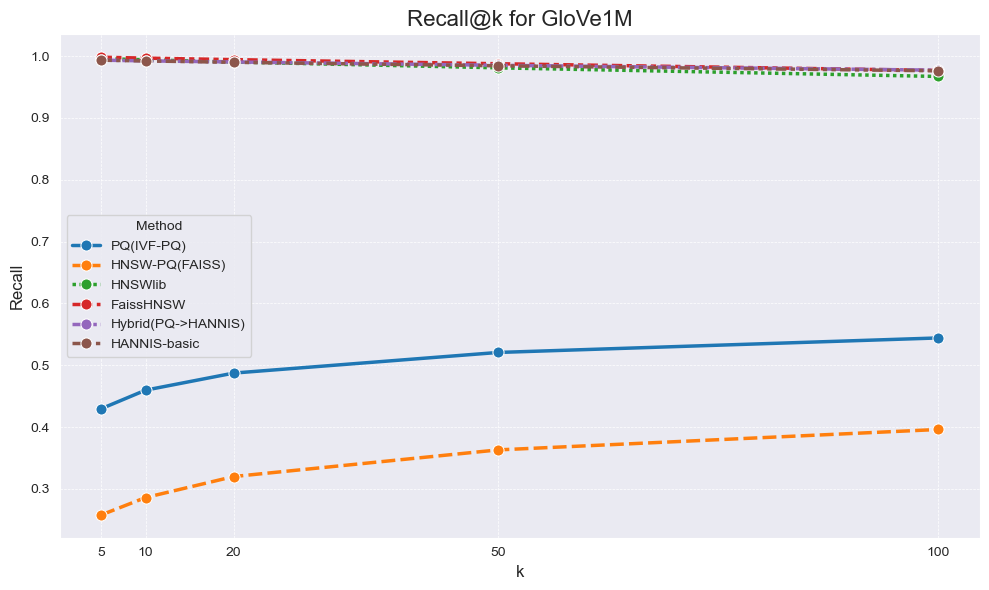

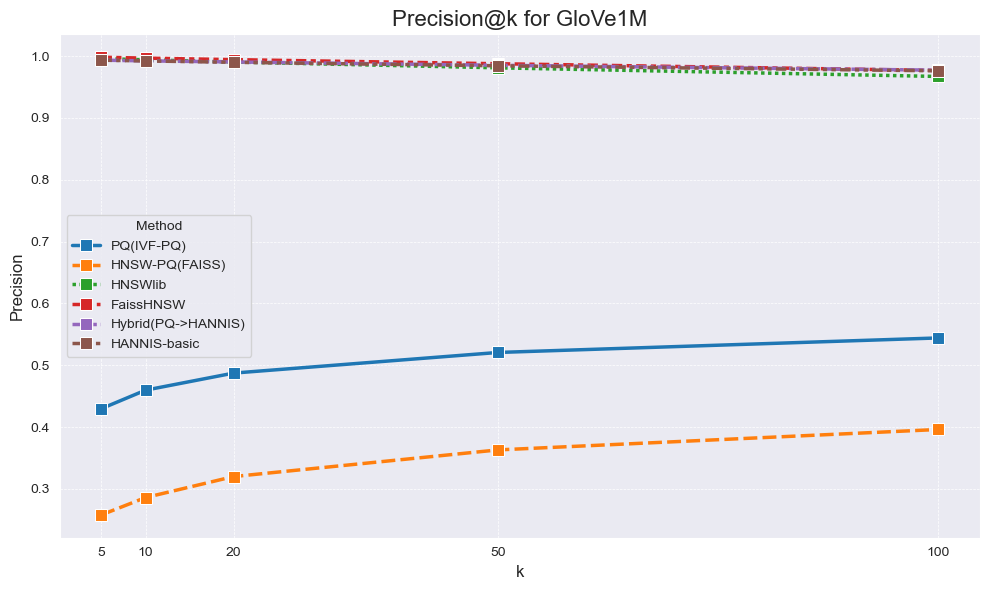

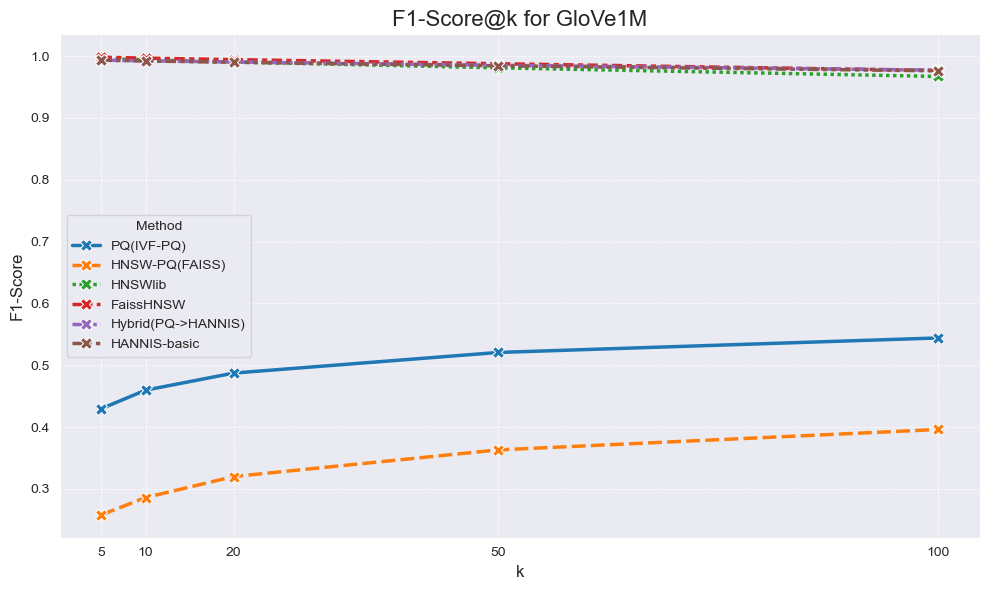

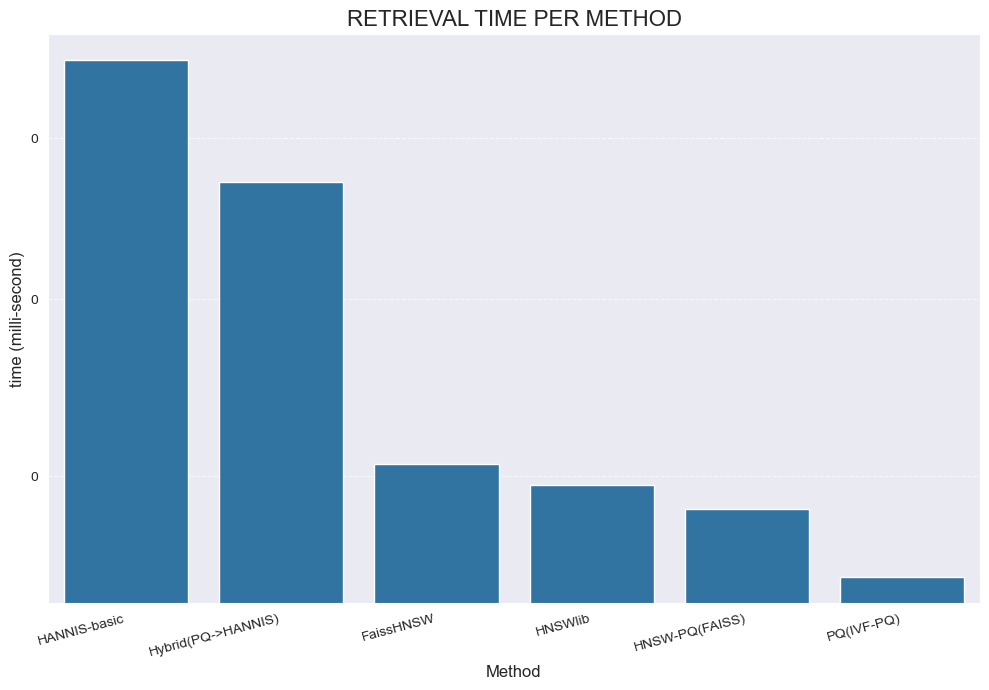

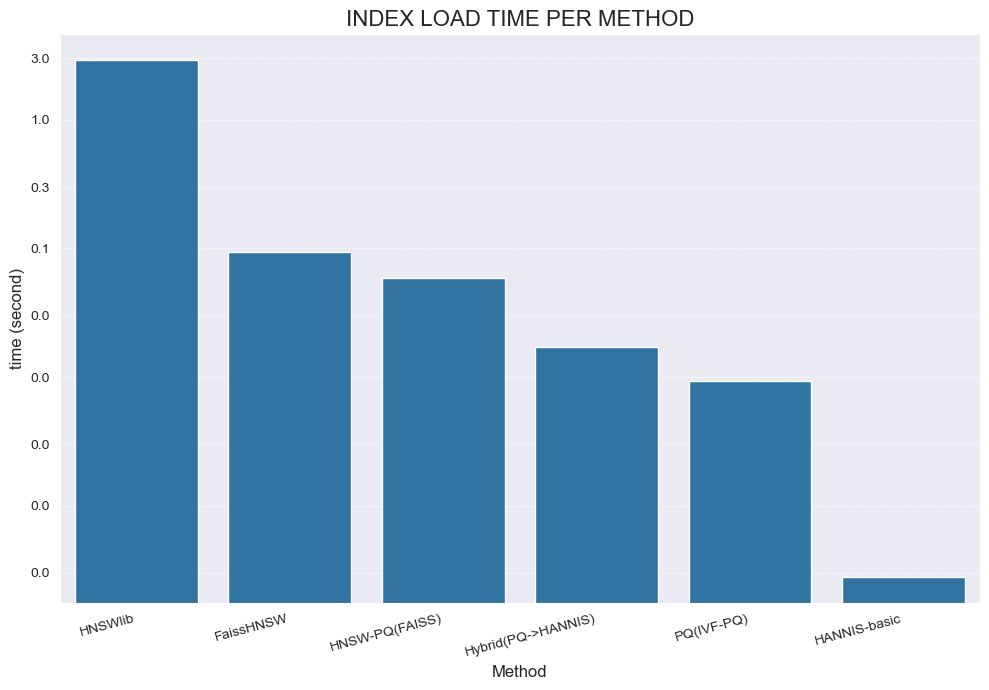

<Figure size 1000x600 with 0 Axes>

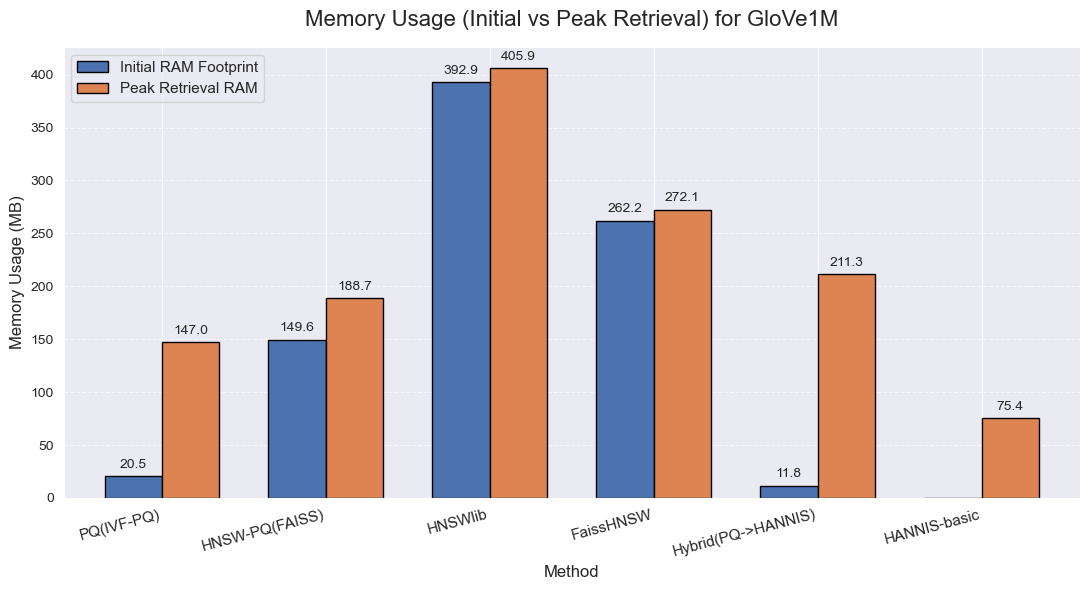

In [18]:
summary_path = os.path.join(BASE, "results", f"{DATASET}_summary.csv")
summary = pd.read_csv(summary_path)

for col in ["total_index_load_s", "latency_mean_s_per_query", "index_loading_s_per_query"]:
    if col not in summary.columns:
        summary[col] = np.nan

# แปลงโครงสร้างตารางจากแนวนอนเป็นแนวตั้ง ให้ไลบรารี Seaborn นำไปวาดกราฟเส้น
def melt_metric(df, metric_prefix):
    cols = [f"{metric_prefix}@{k}" for k in KS]
    for c in cols:
        if c not in df.columns:
            df[c] = np.nan
    melted = df[["method"] + cols].melt(
        id_vars="method", # ให้คอลัมน์ method เป็นแกนหลักที่ไม่ต้องถูกยุบ
        value_vars=cols, # ยุบคอลัมน์พวก recall@5, recall@10
        var_name="k", # เก็บชื่อคอลัมน์เดิม
        value_name="score" # เก็บคะแนน
    )
    melted['k'] = melted['k'].str.extract(r"@(\d+)").astype(int) # ดึงเฉพาะตัวเลขออกมาจาก recall@5, recall@10 เพื่อเก็บแค่ตัวเลข k ตัว
    return melted

# ปรับแกน Y ของกราฟแท่งให้เป็น Log Scale
def _apply_log_axis_ms(ax):
    ax.set_yscale('log')
    ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1, 3)))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.0f}')) # ไม่มีทศนิยม
    ax.grid(axis='y', linestyle='--', alpha=0.7)

def _apply_log_axis_s(ax):
    ax.set_yscale('log')
    ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1, 3)))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.1f}')) # มีทศนิยม 1 ตำแหน่ง
    ax.grid(axis='y', linestyle='--', alpha=0.7)

# 1) Recall@k (Line plot)
recall_df = melt_metric(summary, "recall")
plt.figure(figsize=(10, 6))
ax = sns.lineplot(
    data=recall_df, x="k", y="score",
    hue="method", style="method", marker='o', lw=2.5, markersize=8
)
plt.title(f'Recall@k for {DATASET}', fontsize=16)
plt.xlabel('k', fontsize=12)
plt.ylabel('Recall', fontsize=12)
plt.xticks(KS)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(title='Method')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"{DATASET}_recall_at_k.png"), dpi=150)

# 2) Precision@k (Line plot)
precision_df = melt_metric(summary, "precision")
plt.figure(figsize=(10, 6))
ax = sns.lineplot(
    data=precision_df, x="k", y="score",
    hue="method", style="method", marker='s', lw=2.5, markersize=8
)
plt.title(f'Precision@k for {DATASET}', fontsize=16)
plt.xlabel('k', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.xticks(KS)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(title='Method')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"{DATASET}_precision_at_k.png"), dpi=150)

# 3) F1-score@k (Line plot)
f1_df = melt_metric(summary, "f1")
plt.figure(figsize=(10, 6))
ax = sns.lineplot(
    data=f1_df, x="k", y="score",
    hue="method", style="method", marker='X', lw=2.5, markersize=8
)
plt.title(f'F1-Score@k for {DATASET}', fontsize=16)
plt.xlabel('k', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.xticks(KS)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(title='Method')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"{DATASET}_f1_at_k.png"), dpi=150)

# 4) Retrieval latency (mean s/query) - Vertical Bar Plot
# latency_mean_s_per_query -> แปลงวินาที เป็น มิลลิวินาที (* 1000.0)
plt.figure(figsize=(10, 7))
plot_data = summary.sort_values("latency_mean_s_per_query", ascending=False).copy()
plot_data["latency_mean_ms_per_query"] = plot_data["latency_mean_s_per_query"] * 1000.0

ax = sns.barplot(data=plot_data, x="method", y="latency_mean_ms_per_query")
plt.title('RETRIEVAL TIME PER METHOD', fontsize=16)
plt.xlabel('Method', fontsize=12)
plt.ylabel('time (milli-second)', fontsize=12)
_apply_log_axis_ms(ax)  # log-scale ในหน่วย ms
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"{DATASET}_retrieval_time_ms.png"), dpi=150)

# 5) Total Initial Index Loading Time - Vertical Bar Plot
plt.figure(figsize=(10, 7))
plot_data = summary.sort_values("total_index_load_s", ascending=False).copy()
ax = sns.barplot(data=plot_data, x="method", y="total_index_load_s")
plt.title('INDEX LOAD TIME PER METHOD', fontsize=16)
plt.xlabel('Method', fontsize=12)
plt.ylabel('time (second)', fontsize=12)
_apply_log_axis_s(ax)  # log-scale วินาที
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"{DATASET}_total_loading_time_s.png"), dpi=150)

# 6) กราฟเปรียบเทียบ Memory Usage (Initial vs Peak RAM)
plt.figure(figsize=(10, 6))

# ดึงข้อมูลเฉพาะคอลัมน์ที่เกี่ยวกับ RAM และตั้ง Index เป็นชื่อวิธี
mem_df = summary.set_index('method')[['initial_ram_mb', 'peak_retrieval_ram_mb']]

# สร้างกราฟแท่งคู่ (Grouped Bar Chart)
ax = mem_df.plot(kind='bar', figsize=(11, 6), color=['#4C72B0', '#DD8452'], width=0.7, edgecolor='black')

plt.title(f'Memory Usage (Initial vs Peak Retrieval) for {DATASET}', fontsize=16, pad=15)
plt.xlabel('Method', fontsize=12)
plt.ylabel('Memory Usage (MB)', fontsize=12)
plt.xticks(rotation=15, ha='right', fontsize=11)
plt.legend(['Initial RAM Footprint', 'Peak Retrieval RAM'], fontsize=11, loc='upper left')

# เติมตัวเลขกำกับบนยอดแท่งกราฟทุกแท่ง
for p in ax.patches:
    height = p.get_height()
    if height > 0: # ป้องกันการเขียนทับกันถ้ายอดเป็น 0
        ax.annotate(f'{height:.1f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10, xytext=(0, 4), textcoords='offset points')

# เพิ่ม Grid แนวนอนให้อ่านค่าง่ายขึ้น
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
mem_fig_path = os.path.join(FIG_DIR, f"{DATASET}_memory_usage_ram.png")
plt.savefig(mem_fig_path, dpi=150)
print(f"Saved RAM Memory Usage plot to: {mem_fig_path}")

plt.show()